In [2]:
import pandas as pd
print("Environment working successfully")

Environment working successfully


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [8]:

train = pd.read_csv("../data/train.csv", parse_dates=["Date"])
test = pd.read_csv("../data/test.csv", parse_dates=["Date"])
store = pd.read_csv("../data/store.csv")


print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Store shape:", store.shape)

train.head()


Train shape: (1017209, 9)
Test shape: (41088, 8)
Store shape: (1115, 10)


C:\Users\chait\AppData\Local\Temp\ipykernel_28216\1679171129.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv", parse_dates=["Date"])


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [9]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [10]:
test.head()

,Id,Store,DayOfWeek,Date,Open,Promo,StateHoliday,SchoolHoliday
0,1,1,4,2015-09-17,1.0,1,0,0
1,2,3,4,2015-09-17,1.0,1,0,0
2,3,7,4,2015-09-17,1.0,1,0,0
3,4,8,4,2015-09-17,1.0,1,0,0
4,5,9,4,2015-09-17,1.0,1,0,0


In [11]:
df = pd.merge(train, store, on="Store", how="left")

In [12]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [13]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Promo2SinceWeek              508031
PromoInterval                508031
Promo2SinceYear              508031
CompetitionOpenSinceYear     323348
CompetitionOpenSinceMonth    323348
CompetitionDistance            2642
dtype: int64

In [14]:
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("Number of stores:", df['Store'].nunique())
print("Total rows:", len(df))
print("Columns:", df.columns.tolist())


Date range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00
Number of stores: 1115
Total rows: 1017209
Columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [15]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
Store,1017209.0,558.429727,1.0,280.0,558.0,838.0,1115.0,321.908651
DayOfWeek,1017209.0,3.998341,1.0,2.0,4.0,6.0,7.0,1.997391
Date,1017209,2014-04-11 01:30:42.846061824,2013-01-01 00:00:00,2013-08-17 00:00:00,2014-04-02 00:00:00,2014-12-12 00:00:00,2015-07-31 00:00:00,NaN
Sales,1017209.0,5773.818972,0.0,3727.0,5744.0,7856.0,41551.0,3849.926175
Customers,1017209.0,633.145946,0.0,405.0,609.0,837.0,7388.0,464.411734
Open,1017209.0,0.830107,0.0,1.0,1.0,1.0,1.0,0.375539
Promo,1017209.0,0.381515,0.0,0.0,0.0,1.0,1.0,0.485759
SchoolHoliday,1017209.0,0.178647,0.0,0.0,0.0,0.0,1.0,0.383056
CompetitionDistance,1014567.0,5430.085652,20.0,710.0,2330.0,6890.0,75860.0,7715.3237
CompetitionOpenSinceMonth,693861.0,7.222866,1.0,4.0,8.0,10.0,12.0,3.211832


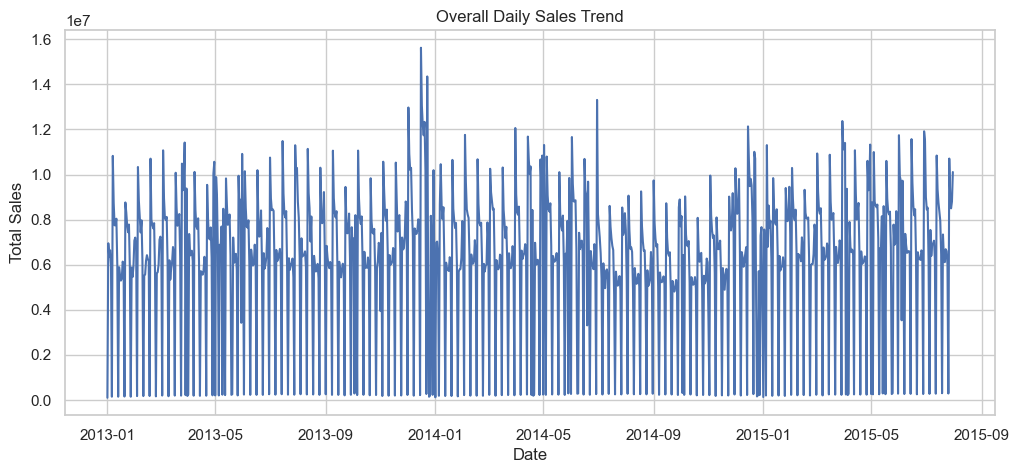

In [16]:
daily_sales = df.groupby("Date")["Sales"].sum().reset_index()

plt.figure(figsize=(12,5))
plt.plot(daily_sales["Date"], daily_sales["Sales"])
plt.title("Overall Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.show()


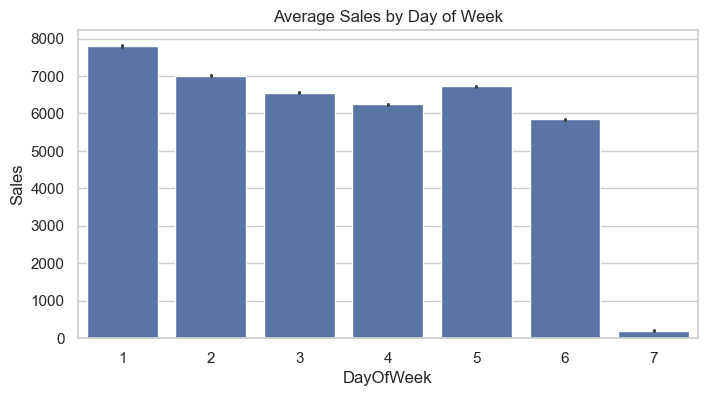

In [17]:
plt.figure(figsize=(8,4))
sns.barplot(x="DayOfWeek", y="Sales", data=df)
plt.title("Average Sales by Day of Week")
plt.show()


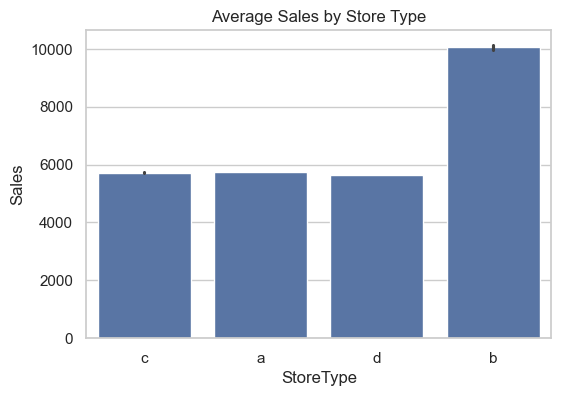

In [18]:
plt.figure(figsize=(6,4))
sns.barplot(x="StoreType", y="Sales", data=df)
plt.title("Average Sales by Store Type")
plt.show()


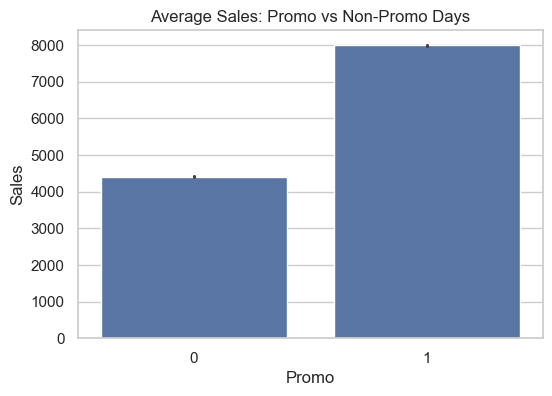

In [19]:
plt.figure(figsize=(6,4))
sns.barplot(x="Promo", y="Sales", data=df)
plt.title("Average Sales: Promo vs Non-Promo Days")
plt.show()


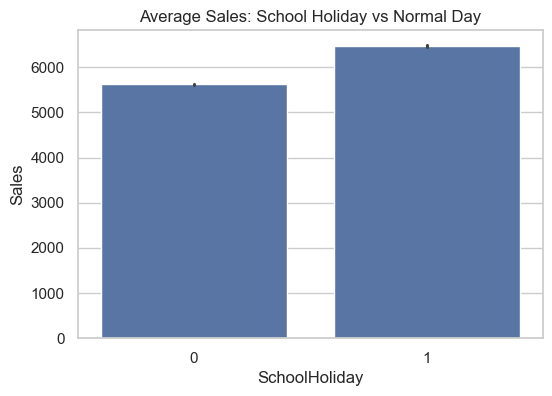

In [20]:
plt.figure(figsize=(6,4))
sns.barplot(x="SchoolHoliday", y="Sales", data=df)
plt.title("Average Sales: School Holiday vs Normal Day")
plt.show()


In [21]:
df.to_csv("../data/merged_train.csv", index=False)
print("Merged dataset saved successfully!")

Merged dataset saved successfully!
